# MeSH KG — Steps 3 & 4: Co-occurrence Edges & Typed Relations

Picks up from `mesh_kg.ipynb` (which produced `mesh_kg_nodes.parquet`,
`mesh_kg_edges_hierarchy.parquet`, `mesh_descriptors.parquet`, and
`mesh_annotations_long.parquet`).

| Step | Task | Output |
|------|------|--------|
| **3** | Count MeSH co-occurrences across papers | `mesh_kg_edges_cooccurrence.parquet` |
| **4** | Promote high-confidence pairs to typed relations | `mesh_kg_edges_typed.parquet` |
| — | Stack all edge sources | `mesh_kg_edges_all.parquet` |

**Unified schema** (must match across all KG sources):
- Nodes: `node_id`, `name`, `node_type`, `source`
- Edges: `subject_id`, `relation_type`, `object_id`, `source`, `weight`

**Node filtering**: all 31 K MeSH descriptors are kept as nodes.  
`NEURO_TREE_PREFIXES` is used only to filter *co-occurrence edges*, not nodes.

In [18]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from collections import Counter
from pathlib import Path
from tqdm.auto import tqdm

from neurovlm.gnn.mesh import NEURO_TREE_PREFIXES

OUT = Path("data/mesh_kg")
OUT.mkdir(parents=True, exist_ok=True)

print("NEURO_TREE_PREFIXES:", NEURO_TREE_PREFIXES)

NEURO_TREE_PREFIXES: {'F01', 'F02', 'C10', 'C23', 'A08', 'D02', 'F03', 'D12'}


## Load Step-2 artifacts

In [19]:
desc_df      = pd.read_parquet(OUT / "mesh_descriptors.parquet")   # ui, name, tree_numbers, synonyms
nodes_df     = pd.read_parquet(OUT / "mesh_kg_nodes.parquet")       # node_id, name, node_type, source
hier_edges   = pd.read_parquet(OUT / "mesh_kg_edges_hierarchy.parquet")
annot_long   = pd.read_parquet(OUT / "mesh_annotations_long.parquet")  # pmid, mesh_term

print(f"Descriptors      : {len(desc_df):>8,}")
print(f"Nodes            : {len(nodes_df):>8,}")
print(f"Hierarchy edges  : {len(hier_edges):>8,}")
print(f"Annotation rows  : {len(annot_long):>8,}")
annot_long.head(3)

Descriptors      :   31,110
Nodes            :   31,110
Hierarchy edges  :   42,519
Annotation rows  : 14,470,827


,pmid,mesh_term
0,41747334,Humans
1,41747334,Ischemic Stroke/diagnosis
2,41747334,"Diagnosis, Differential"


## Build lookup tables

- `name_to_ui`: descriptor name → DescriptorUI  
- `ui_to_prefixes`: DescriptorUI → set of 3-char tree-number prefixes  
- `neuro_uis`: set of UIs that have at least one NEURO_TREE_PREFIX

In [20]:
# name → ui
name_to_ui: dict[str, str] = dict(zip(desc_df["name"], desc_df["ui"]))

# ui → set of 3-char prefixes (first three chars of each tree number)
ui_to_prefixes: dict[str, set[str]] = {
    row["ui"]: {tn[:3] for tn in row["tree_numbers"]}
    for _, row in desc_df.iterrows()
}

# UIs whose tree numbers overlap with NEURO_TREE_PREFIXES
neuro_uis: set[str] = {
    ui for ui, prefs in ui_to_prefixes.items()
    if prefs & NEURO_TREE_PREFIXES
}

print(f"Name→UI entries  : {len(name_to_ui):,}")
print(f"Neuro-relevant UIs: {len(neuro_uis):,} / {len(ui_to_prefixes):,}")

Name→UI entries  : 31,110
Neuro-relevant UIs: 9,284 / 31,110


## Prepare annotation table

Annotation terms arrive as `"Hippocampus/physiology"` — strip the qualifier
after `/` to recover the descriptor name, then look up its DescriptorUI.

In [21]:
annot = annot_long.copy()

# Strip qualifier to get descriptor name
annot["descriptor_name"] = annot["mesh_term"].str.split("/").str[0]

# Map to DescriptorUI
annot["ui"] = annot["descriptor_name"].map(name_to_ui)

n_total   = len(annot)
n_mapped  = annot["ui"].notna().sum()
n_missing = n_total - n_mapped

print(f"Total annotation rows  : {n_total:>10,}")
print(f"Successfully mapped    : {n_mapped:>10,}  ({100*n_mapped/n_total:.1f}%)")
print(f"Unmapped (dropped)     : {n_missing:>10,}  ({100*n_missing/n_total:.1f}%)")

# Drop unmapped terms and deduplicate (same term listed twice for a paper is fine)
annot = (
    annot.dropna(subset=["ui"])[["pmid", "ui"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

print(f"\nDeduped (pmid, ui) rows: {len(annot):>10,}")
print(f"Unique PMIDs           : {annot['pmid'].nunique():>10,}")

Total annotation rows  : 14,470,827
Successfully mapped    : 14,470,827  (100.0%)
Unmapped (dropped)     :          0  (0.0%)

Deduped (pmid, ui) rows: 12,169,002
Unique PMIDs           :  1,032,953


---
## Step 3 — Co-occurrence triples

For each paper emit one edge for every pair of its MeSH descriptors, then:
1. Keep only pairs where **at least one** descriptor is neuro-relevant (`NEURO_TREE_PREFIXES`)
2. Count frequency across all papers
3. Apply minimum support ≥ 10 papers

Output: `(subject_id, co_occurs_with, object_id, source="mesh", weight=N_papers)`

> **Expected runtime**: ~1–3 minutes for 1 M papers with 14 average terms each.

In [22]:
# Group by paper → sorted list of unique UIs
paper_uids = annot.groupby("pmid")["ui"].agg(list)
print(f"Papers with ≥1 mapped MeSH term: {len(paper_uids):,}")

pair_counts: Counter = Counter()

for uid_list in tqdm(paper_uids, desc="Co-occurrence pairs", unit="paper"):
    uid_list = sorted(set(uid_list))  # canonical ordering, dedup within paper
    # Skip papers with no neuro term — they can't contribute a neuro pair
    if not any(u in neuro_uis for u in uid_list):
        continue
    for a, b in combinations(uid_list, 2):
        # At least one side must be neuro
        if a in neuro_uis or b in neuro_uis:
            pair_counts[(a, b)] += 1

print(f"\nRaw neuro pairs before support filter: {len(pair_counts):,}")

Papers with ≥1 mapped MeSH term: 1,032,953


Co-occurrence pairs:   0%|          | 0/1032953 [00:00<?, ?paper/s]


Raw neuro pairs before support filter: 2,814,836


In [23]:
MIN_SUPPORT = 10

cooc_edges = pd.DataFrame(
    [(a, b, cnt) for (a, b), cnt in pair_counts.items() if cnt >= MIN_SUPPORT],
    columns=["subject_id", "object_id", "weight"],
)
cooc_edges["relation_type"] = "co_occurs_with"
cooc_edges["source"]        = "mesh"
cooc_edges = cooc_edges[["subject_id", "relation_type", "object_id", "source", "weight"]]

print(f"Co-occurrence edges (support ≥ {MIN_SUPPORT}): {len(cooc_edges):,}")
print(f"\nWeight distribution:")
cooc_edges["weight"].describe().apply(lambda x: f"{x:,.1f}")

Co-occurrence edges (support ≥ 10): 257,290

Weight distribution:


count    257,290.0
mean          82.8
std          636.1
min           10.0
25%           13.0
50%           21.0
75%           46.0
max      158,330.0
Name: weight, dtype: str

In [24]:
out_cooc = OUT / "mesh_kg_edges_cooccurrence.parquet"
cooc_edges.to_parquet(out_cooc, index=False)
print(f"Saved {len(cooc_edges):,} co-occurrence edges → {out_cooc}")
cooc_edges.head(5)

Saved 257,290 co-occurrence edges → data/mesh_kg/mesh_kg_edges_cooccurrence.parquet


,subject_id,relation_type,object_id,source,weight
0,D001921,co_occurs_with,D006801,mesh,158330
1,D001921,co_occurs_with,D008279,mesh,103503
2,D001921,co_occurs_with,D011603,mesh,162
3,D001921,co_occurs_with,D011859,mesh,1813
4,D001921,co_occurs_with,D014796,mesh,3439


---
## Step 4 — Promote to typed relations

For pairs co-occurring in **≥ 50 papers**, inspect the tree-number prefixes of
both endpoints and assign a stronger relation type (first rule that matches wins):

| Endpoint A prefixes | Endpoint B prefixes | Typed relation |
|---------------------|---------------------|----------------|
| `A08` | `F01` or `F02` | `implicated_in` |
| `A08` | `F03` or any `C` prefix | `associated_with_disorder` |
| `D12` or `D02` | `A08` | `expressed_in` |
| `A08` | `A08` | `co_activates_with` |

**Notes on coverage:**
- `F03` (mental disorders — depression, schizophrenia, anxiety, …) is included
  explicitly because psychiatric conditions live under `F03.*`, not `C.*`.
- `C23` (pathological conditions, signs & symptoms — atrophy, seizures, cognitive
  decline) is caught by the `any C prefix` branch → `associated_with_disorder`.
- `D02` covers organic chemicals broadly, including neurotransmitters such as
  dopamine and serotonin — `expressed_in` for `D02×A08` captures these triples.
- Pairs that match no rule (e.g. neuro anatomy × demographic term, or
  neuro anatomy × imaging method) remain as `co_occurs_with` only.

The original `co_occurs_with` edge is **kept alongside** the typed edge.


In [25]:
def assign_typed_relation(
    ui_a: str,
    ui_b: str,
    ui_to_prefixes: dict[str, set[str]],
) -> str | None:
    """Return a typed relation for the (ui_a, ui_b) pair, or None if no rule matches.

    Rules are applied in priority order; first match wins.
    Both (a→b) and (b→a) orientations are tried for each rule.

    Rule table
    ----------
    A08 + F01/F02             → implicated_in           (neuro anatomy × behaviour/psychology)
    A08 + F03 / any C prefix  → associated_with_disorder (neuro anatomy × psychiatric or neurological disease)
    D12/D02 + A08             → expressed_in            (protein or bioactive small molecule × neuro anatomy)
    A08 + A08                 → co_activates_with       (two neuro-anatomical regions)

    Notes
    -----
    - D02 covers organic chemicals broadly, including neurotransmitters (dopamine,
      serotonin) and neuroactive drugs — not just proteins.  expressed_in for D02×A08
      captures high-value triples like dopamine→striatum.
    - C23 (pathological conditions, signs & symptoms) is intentionally handled by
      the 'any C prefix' branch — e.g. atrophy or seizures co-occurring with a brain
      region get associated_with_disorder, which is appropriate.
    - F03 (mental disorders: depression, schizophrenia, …) is explicitly included
      because psychiatric conditions are not under C* tree numbers; they are F03.*.
    """
    pa = ui_to_prefixes.get(ui_a, set())
    pb = ui_to_prefixes.get(ui_b, set())

    def _match(x_prefs: set[str], y_prefs: set[str]) -> str | None:
        # Priority 1 — A08 (anatomy) + F01/F02 (behaviour/psychology) → implicated_in
        if "A08" in x_prefs and (y_prefs & {"F01", "F02"}):
            return "implicated_in"
        # Priority 2 — A08 (anatomy) + F03 (psychiatric disorders) OR any C (disease) → associated_with_disorder
        if "A08" in x_prefs and ("F03" in y_prefs or any(p.startswith("C") for p in y_prefs)):
            return "associated_with_disorder"
        # Priority 3 — D12 (proteins/peptides) or D02 (organic chemicals incl. neurotransmitters) + A08 → expressed_in
        if (x_prefs & {"D12", "D02"}) and "A08" in y_prefs:
            return "expressed_in"
        return None

    # Try both orientations
    result = _match(pa, pb) or _match(pb, pa)
    if result:
        return result

    # Priority 4 — A08 × A08 (two neuro-anatomical regions) → co_activates_with
    if "A08" in pa and "A08" in pb:
        return "co_activates_with"

    return None


In [26]:
TYPED_MIN_SUPPORT = 50

high_conf = cooc_edges[cooc_edges["weight"] >= TYPED_MIN_SUPPORT].copy()
print(f"High-confidence pairs (support ≥ {TYPED_MIN_SUPPORT}): {len(high_conf):,}")

# Assign typed relation
high_conf["relation_type"] = [
    assign_typed_relation(a, b, ui_to_prefixes)
    for a, b in zip(high_conf["subject_id"], high_conf["object_id"])
]

# Drop pairs where no rule matched
typed_edges = (
    high_conf.dropna(subset=["relation_type"])
    [["subject_id", "relation_type", "object_id", "source", "weight"]]
    .reset_index(drop=True)
)

print(f"Pairs with a typed relation      : {len(typed_edges):,}")
print(f"Pairs with no matching rule      : {len(high_conf) - len(typed_edges):,}")
print()
print("Typed relation distribution:")
print(typed_edges["relation_type"].value_counts().to_string())

High-confidence pairs (support ≥ 50): 59,567
Pairs with a typed relation      : 5,418
Pairs with no matching rule      : 54,149

Typed relation distribution:
relation_type
associated_with_disorder    2107
implicated_in               1803
co_activates_with            931
expressed_in                 577


In [27]:
# Diagnostic: what tree-prefix combinations are in the unmatched high-confidence pairs?
# This reveals whether important neuro–neuro pairs are being missed by the rule table.
unmatched = high_conf[high_conf["relation_type"].isna()].copy()
print(f"Unmatched high-confidence pairs: {len(unmatched):,} / {len(high_conf):,} "
      f"({100*len(unmatched)/len(high_conf):.1f}%)")
print()

def _top_prefix(ui: str) -> str:
    """Return the single most-specific 3-char tree prefix for a UI, or '???' if unknown."""
    prefs = sorted(ui_to_prefixes.get(ui, set()))
    return prefs[0] if prefs else "???"

unmatched["prefix_a"] = unmatched["subject_id"].map(_top_prefix)
unmatched["prefix_b"] = unmatched["object_id"].map(_top_prefix)

# Canonical pair key so (A08, C10) and (C10, A08) bucket together
unmatched["prefix_pair"] = unmatched.apply(
    lambda r: tuple(sorted([r["prefix_a"], r["prefix_b"]])), axis=1
)

top_pairs = unmatched["prefix_pair"].value_counts().head(20)
print("Top 20 unmatched prefix-pair combinations:")
print(top_pairs.to_string())
print()
print("Interpretation guide:")
print("  A08 = neuro anatomy    F01/F02 = behaviour    F03 = mental disorders")
print("  C*  = diseases         D12/D02 = molecular    E*  = methods")
print("  G*  = bio phenomena    M*      = persons/demog  N*  = health services")


Unmatched high-confidence pairs: 54,149 / 59,567 (90.9%)

Top 20 unmatched prefix-pair combinations:
prefix_pair
(C10, E01)    2245
(C10, M01)    1842
(A08, E01)    1498
(C10, E05)    1254
(A08, E05)    1074
(C23, E01)    1047
(A08, M01)     942
(B01, D12)     923
(E01, F02)     891
(???, C10)     788
(A08, B01)     782
(C10, C10)     751
(D02, E01)     751
(B01, C10)     731
(E05, F02)     730
(F02, F02)     715
(B01, D02)     704
(D12, M01)     667
(C23, M01)     659
(D12, E01)     648

Interpretation guide:
  A08 = neuro anatomy    F01/F02 = behaviour    F03 = mental disorders
  C*  = diseases         D12/D02 = molecular    E*  = methods
  G*  = bio phenomena    M*      = persons/demog  N*  = health services


In [28]:
out_typed = OUT / "mesh_kg_edges_typed.parquet"
typed_edges.to_parquet(out_typed, index=False)
print(f"Saved {len(typed_edges):,} typed edges → {out_typed}")
typed_edges.head(5)

Saved 5,418 typed edges → data/mesh_kg/mesh_kg_edges_typed.parquet


,subject_id,relation_type,object_id,source,weight
0,D001921,implicated_in,D011603,mesh,162
1,D001921,implicated_in,D014796,mesh,3439
2,D002543,associated_with_disorder,D002552,mesh,347
3,D002552,associated_with_disorder,D005315,mesh,68
4,D005625,co_activates_with,D008032,mesh,277


---
## Combined edge file

Stack hierarchy + co-occurrence + typed edges into `mesh_kg_edges_all.parquet`.

In [29]:
all_edges = pd.concat(
    [hier_edges, cooc_edges, typed_edges],
    ignore_index=True,
)

out_all = OUT / "mesh_kg_edges_all.parquet"
all_edges.to_parquet(out_all, index=False)

print(f"Total edges in combined file : {len(all_edges):,}")
print(f"Saved → {out_all}")

Total edges in combined file : 305,227
Saved → data/mesh_kg/mesh_kg_edges_all.parquet


---
## Sanity check

In [30]:
print("=" * 50)
print("KG summary")
print("=" * 50)
print(f"Total nodes : {len(nodes_df):>10,}")
print(f"Total edges : {len(all_edges):>10,}")
print()
print("Edge counts by relation type:")
rel_counts = all_edges["relation_type"].value_counts()
for rel, cnt in rel_counts.items():
    print(f"  {rel:<30s}: {cnt:>10,}")

KG summary
Total nodes :     31,110
Total edges :    305,227

Edge counts by relation type:
  co_occurs_with                :    257,290
  narrower_term_of              :     42,519
  associated_with_disorder      :      2,107
  implicated_in                 :      1,803
  co_activates_with             :        931
  expressed_in                  :        577


In [31]:
# Degree distribution (undirected: count each node as subject or object)
degree = (
    pd.concat([
        all_edges[["subject_id"]].rename(columns={"subject_id": "node_id"}),
        all_edges[["object_id"]].rename(columns={"object_id": "node_id"}),
    ])
    ["node_id"]
    .value_counts()
    .rename("degree")
)

print(f"Nodes with ≥1 edge : {len(degree):,} / {len(nodes_df):,}")
print(f"Isolated nodes     : {len(nodes_df) - len(degree):,}")
print()
print("Degree distribution summary:")
print(degree.describe().apply(lambda x: f"{x:,.1f}").to_string())

Nodes with ≥1 edge : 31,110 / 31,110
Isolated nodes     : 0

Degree distribution summary:
count    31,110.0
mean         19.6
std         105.4
min           1.0
25%           1.0
50%           2.0
75%           8.0
max       7,157.0


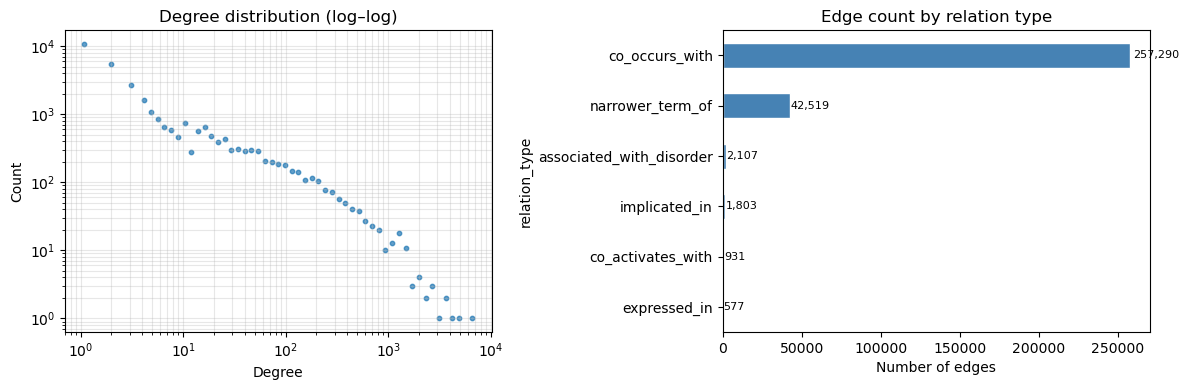

Plot saved → data/mesh_kg/mesh_kg_degree_distribution.png


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: log-log degree distribution (power-law check)
deg_vals = degree.values
counts, bins = np.histogram(deg_vals, bins=np.logspace(0, np.log10(deg_vals.max()), 60))
bin_centers = 0.5 * (bins[:-1] + bins[1:])
mask = counts > 0
axes[0].scatter(bin_centers[mask], counts[mask], s=10, alpha=0.7)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("Degree")
axes[0].set_ylabel("Count")
axes[0].set_title("Degree distribution (log–log)")
axes[0].grid(True, which="both", alpha=0.3)

# Right: edge counts by relation type
rel_counts.plot(kind="barh", ax=axes[1], color="steelblue", edgecolor="white")
axes[1].set_xlabel("Number of edges")
axes[1].set_title("Edge count by relation type")
axes[1].invert_yaxis()
for bar in axes[1].patches:
    w = bar.get_width()
    axes[1].text(
        w * 1.01, bar.get_y() + bar.get_height() / 2,
        f"{int(w):,}", va="center", fontsize=8,
    )

plt.tight_layout()
plt.savefig(OUT / "mesh_kg_degree_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved →", OUT / "mesh_kg_degree_distribution.png")

## Summary

| File | Contents |
|------|----------|
| `mesh_kg_edges_cooccurrence.parquet` | `co_occurs_with` triples, weight = paper count, support ≥ 10 |
| `mesh_kg_edges_typed.parquet` | typed semantic triples for high-confidence pairs (support ≥ 50) |
| `mesh_kg_edges_all.parquet` | union of hierarchy + co-occurrence + typed edges |
| `mesh_kg_degree_distribution.png` | log–log degree distribution + relation-type bar chart |

**Typed relations assigned**:
- `implicated_in` — neuro anatomy (A08) co-occurs with behavior/psychology (F01/F02)
- `associated_with_disorder` — neuro anatomy (A08) co-occurs with disease (C*)
- `expressed_in` — protein/chemical (D12/D02) co-occurs with neuro anatomy (A08)
- `co_activates_with` — two neuro anatomy descriptors (A08 × A08)

**Next steps**: integrate this MeSH KG with the NLP KG and other sources into the unified multi-modal graph.